# F70TS Machine Learning (Week 9)
## Bias-variance and cross-validation
### Task 1: Data Preprocessing
- Load the Wine dataset using `sklearn.datasets.load_wine()`. Use the Wine dataset from `sklearn.datasets`. This dataset contains 178 instances of wine samples, classified into 3 classes, with 13 features describing the chemical properties of each wine sample.
- Split the dataset into a training set (80%) and a test set (20%).
- Standardize the features using `StandardScaler()` from `sklearn.preprocessing`.

In [27]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the dataset
wine = load_wine()
data = pd.DataFrame(wine.data, columns=wine.feature_names)
data["target"] = wine.target

# data
X = wine.data
y = wine.target

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# Normalize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Task 2: Analysing overfitting and Bias-Variance in decision trees
- Train a decision tree classifier on the training set using `sklearn.tree.DecisionTreeClassifier`.
- Start by training the model with no constraints (e.g., no depth limit).
- Plot the decision tree's accuracy on both the training set and test set.
- Repeat the training process with different values for the `max_depth` parameter (e.g., 2, 4, 6, 8, 10).
- Plot the training and test accuracy as a function of tree depth.

Training accuracy (no limit): 1.000
Test accuracy (no limit): 0.972


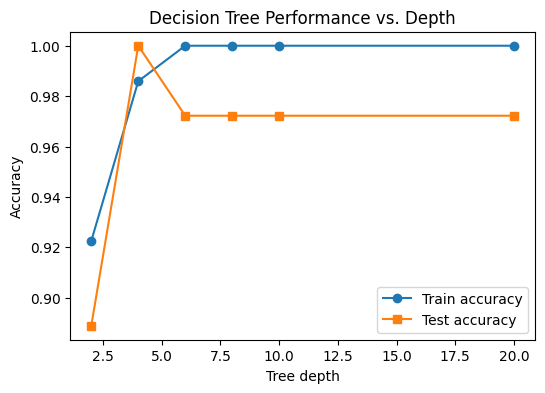

In [28]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn import tree
import matplotlib.pyplot as plt


# Train an unconstrained tree
dt_full = DecisionTreeClassifier(random_state=123)
dt_full.fit(X_train, y_train)

# Compute accuracies
train_acc = accuracy_score(y_train, dt_full.predict(X_train))
test_acc = accuracy_score(y_test, dt_full.predict(X_test))

print(f"Training accuracy (no limit): {train_acc:.3f}")
print(f"Test accuracy (no limit): {test_acc:.3f}")

depths = [2, 4, 6, 8, 10, None]  # None = full tree
train_scores, test_scores = [], []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=123)
    model.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, model.predict(X_train)))
    test_scores.append(accuracy_score(y_test, model.predict(X_test)))

plt.figure(figsize=(6,4))
plt.plot([d if d else 20 for d in depths], train_scores, marker='o', label='Train accuracy')
plt.plot([d if d else 20 for d in depths], test_scores, marker='s', label='Test accuracy')
plt.xlabel("Tree depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Performance vs. Depth")
plt.legend()
plt.show()



**Q1: What do you observe regarding the training and test accuracy? Explain whether the model is overfitting or underfitting.**
- Training accuracy: given that the tree depth is not constrained (we do not impose a limit on the depth of the tree), the model perfectly fits the training data, leading to a training accuracy of 100%. This is a sign of overfitting.
- Test accuracy: The test accuracy is lower than training accuracy. This hints to potentially the tree is overfitting to the training data, capturing noise and specific patterns that don't generalise well to unseen data.

**Q2: Discuss how increasing the depth of the tree affects bias and variance.**
- Training accuracy trend: As the depth increases, the training accuracy improves, reaching 100% as the tree becomes more complex and fits the data more precisely. However, beyond a certain point, further increasing the depth doesn't improve generalisation but just overfits the training data.
- Test accuracy trend: Initially, as the depth increases, test accuracy improves. However, after a depth 4, the test accuracy plateaus due to overfitting. This point of inflection reflects the optimal depth where the bias-variance trade-off is minimised.
- Plot analysis: The plot shows training accuracy increasing with depth, while test accuracy first increases and then flattens at high depths. This illustrates overfitting at high depths.

### Task 3: Analysing overfitting and Bias-Variance in k-Nearest Neighbours
- Train a k-Nearest Neighbours classifier on the same dataset using `sklearn.neighbors.KNeighborsClassifier`.
- Vary the k parameter from 1 to 15.
- Plot the accuracy on the training set and test set as a function of k.

**Q3: For small values of k, explain whether the model is more likely to overfit or underfit. What happens as you increase k? Discuss in terms of the bias-variance trade-off.**
- Effect of k on training accuracy: When k=1, the training accuracy is 100% because the model memorises the training data (high variance). As k increases, the training accuracy decreases since the model smoothens decision boundaries.
- Effect of k on test accuracy: Initially, increasing k improves generalisation by reducing overfitting. However, beyond a certain point (e.g., k=5), increasing k causes underfitting, reducing test accuracy.
- Plot analysis: The plot should show that small values of k (e.g., k=1) result in high training accuracy and lower test accuracy (overfitting). At moderate values of k (e.g., k=5), both training and test accuracies are balanced. With larger values of k (e.g., k=15), test accuracy starts to drop due to underfitting (high bias).

Classification report (Euclidean, k=3):
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00         8
     class_1       0.92      1.00      0.96        11
     class_2       1.00      0.94      0.97        17

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.98        36
weighted avg       0.97      0.97      0.97        36

Classification report (Manhattan, k=3):
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00         8
     class_1       0.92      1.00      0.96        11
     class_2       1.00      0.94      0.97        17

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.98        36
weighted avg       0.97      0.97      0.97        36



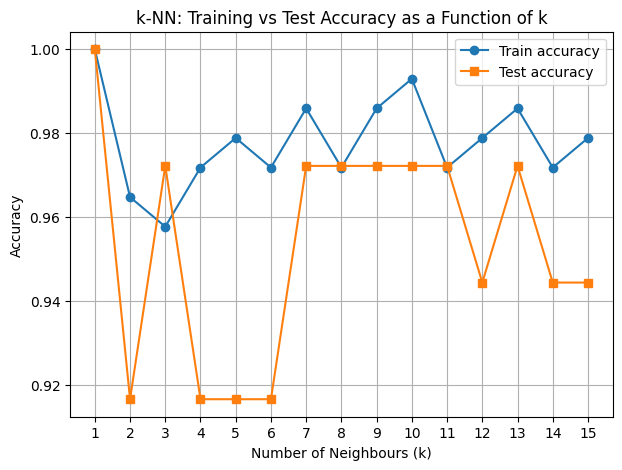

In [29]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt


# Create the kNN model
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# Make predictions and evaluate the model
y_pred = knn.predict(X_test)
print("Classification report (Euclidean, k=3):")
print(classification_report(y_test, y_pred, target_names=wine.target_names))

# Implement kNN with Manhattan distance
knn_manhattan = KNeighborsClassifier(n_neighbors=3, metric='manhattan')
knn_manhattan.fit(X_train, y_train)
y_pred_manhattan = knn_manhattan.predict(X_test)

# Evaluate the model with Manhattan distance
print("Classification report (Manhattan, k=3):")
print(classification_report(y_test, y_pred_manhattan, target_names=wine.target_names))


k_values = range(1, 16)
train_accs, test_accs = [], []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, knn.predict(X_train)))
    test_accs.append(accuracy_score(y_test, knn.predict(X_test)))

plt.figure(figsize=(7, 5))
plt.plot(k_values, train_accs, marker="o", label="Train accuracy")
plt.plot(k_values, test_accs, marker="s", label="Test accuracy")
plt.title("k-NN: Training vs Test Accuracy as a Function of k")
plt.xlabel("Number of Neighbours (k)")
plt.ylabel("Accuracy")
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.show()

### Task 4: Cross-Validation for model selection
- Use 5-fold cross-validation to evaluate the performance of the decision tree and kNN models using `cross_val_score` from `sklearn.model_selection`.
- For the decision tree, perform cross-validation for different values of max_depth.
- For kNN, perform cross-validation for different values of k.

**5-fold cross-validation for Decision-Trees**

[Decision Tree] Best max_depth: 4 (CV acc = 0.905 ± 0.057)


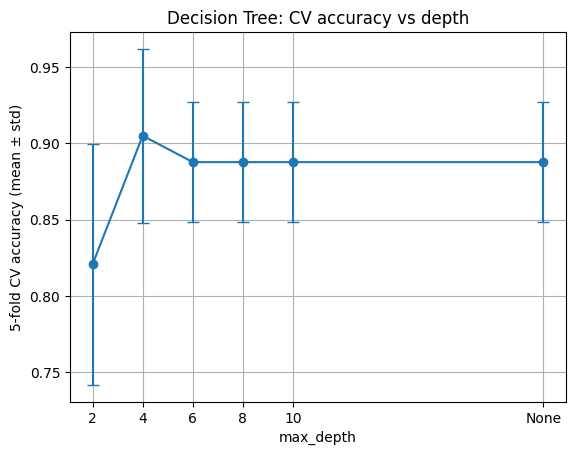

In [30]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
import numpy as np
import matplotlib.pyplot as plt

# Grid of depths to try
depths = [2, 4, 6, 8, 10, None]

dt_means, dt_stds = [], []
for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=123)
    # Use full X, y for CV (5 folds)
    scores = cross_val_score(clf, X, y, cv=5, scoring="accuracy")
    dt_means.append(scores.mean())
    dt_stds.append(scores.std())

# Report best depth
best_idx = int(np.argmax(dt_means))
best_depth = depths[best_idx]
print(f"[Decision Tree] Best max_depth: {best_depth} "
      f"(CV acc = {dt_means[best_idx]:.3f} ± {dt_stds[best_idx]:.3f})")

# Plot mean ± std
plt.figure()
x_vals = [d if d is not None else 20 for d in depths]  # show None as 20 on x-axis
plt.errorbar(x_vals, dt_means, yerr=dt_stds, marker='o', capsize=4, linestyle='-')
plt.xticks(x_vals, [str(d) for d in depths])
plt.xlabel("max_depth")
plt.ylabel("5-fold CV accuracy (mean ± std)")
plt.title("Decision Tree: CV accuracy vs depth")
plt.grid(True)
plt.show()


**5-fold cross-validation for KNN**

[kNN] Best k: 7 (CV acc = 0.967 ± 0.021)


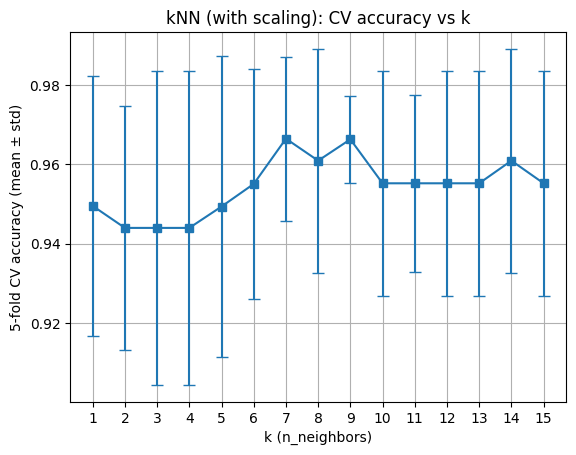

In [31]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

k_values = range(1, 16)

knn_means, knn_stds = [], []
for k in k_values:
    pipe = Pipeline([
        ("scale", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_val_score(pipe, X, y, cv=5, scoring="accuracy")
    knn_means.append(scores.mean())
    knn_stds.append(scores.std())

best_idx = int(np.argmax(knn_means))
best_k = list(k_values)[best_idx]
print(f"[kNN] Best k: {best_k} "
      f"(CV acc = {knn_means[best_idx]:.3f} ± {knn_stds[best_idx]:.3f})")

plt.figure()
plt.errorbar(list(k_values), knn_means, yerr=knn_stds, marker='s', capsize=4, linestyle='-')
plt.xticks(list(k_values))
plt.xlabel("k (n_neighbors)")
plt.ylabel("5-fold CV accuracy (mean ± std)")
plt.title("kNN (with scaling): CV accuracy vs k")
plt.grid(True)
plt.show()


**Q4: Based on the cross-validation results, what is the optimal max_depth for the decision tree? What is the optimal value of k for the kNN model? Compare these results with the performance on the test set.**
- Best depth: The cross-validation results typically show that the optimal tree depth is around 3-5. This is the depth that yields the highest cross-validation accuracy, reaching a balance between bias and variance. Too low a depth leads to underfitting (high bias), while too high a depth leads to overfitting (high variance).
- Cross-Validation plot analysis: The cross-validation plot for decision trees shows that accuracy improves with increasing depth up to a point (e.g., depth 4), after which it starts to decrease slightly due to overfitting.

**Q5: How does cross-validation help in mitigating the risk of overfitting when selecting hyperparameters?**
- Best k value: The cross-validation results indicate that moderate values of k (e.g., k=5) yield the best accuracy. Lower values of k overfit the training data (high variance), while larger values of k underfit (high bias).
- Cross-Validation plot analysis: The cross-validation plot for k-NN shows that the accuracy peaks at around k=5 and starts to decline as k increases due to underfitting.

### Task 5: Model Comparison
- Compare the performance of the decision tree and kNN models on the test set using the optimal hyperparameters selected via cross-validation.

In [32]:
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

# --- Best hyperparameters from cross-validation ---
best_depth = 4      # from Task 4
best_k = 7          # from Task 4

# --- Decision Tree ---
dt_best = DecisionTreeClassifier(max_depth=best_depth, random_state=123)
dt_best.fit(X_train, y_train)
y_pred_dt = dt_best.predict(X_test)
dt_acc = accuracy_score(y_test, y_pred_dt)
print(f"[Decision Tree] max_depth={best_depth} → Test accuracy: {dt_acc:.3f}")

# --- k-Nearest Neighbours (with scaling pipeline) ---
knn_best = Pipeline([
    ("scale", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=best_k))
])
knn_best.fit(X_train, y_train)
y_pred_knn = knn_best.predict(X_test)
knn_acc = accuracy_score(y_test, y_pred_knn)
print(f"[kNN] k={best_k} → Test accuracy: {knn_acc:.3f}")

# --- Side-by-side summary ---
print("\nModel Comparison Summary:")
print(f"Decision Tree (max_depth={best_depth}): {dt_acc:.3f}")
print(f"k-NN (k={best_k}): {knn_acc:.3f}")



[Decision Tree] max_depth=4 → Test accuracy: 1.000
[kNN] k=7 → Test accuracy: 0.972

Model Comparison Summary:
Decision Tree (max_depth=4): 1.000
k-NN (k=7): 0.972


**Q6: Which model performed better on this dataset and why? Discuss in terms of model complexity, bias, and variance.**
When we compare the the DT and kNN models, we notice that
- Decision trees: The best tree depth is usually around 3-5 based on cross-validation results. Beyond this depth, overfitting occurs.
- k-NN: The optimal value of k is around 5 based on cross-validation results. Both very small and very large values of k result in poor generalization.